## Import Packages

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torch.optim import Adam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchmetrics.classification import BinaryPrecision, BinaryRecall, BinaryAUROC, BinaryAveragePrecision, BinaryF1Score
from sklearn.preprocessing import StandardScaler                                               
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve      
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from joblib import dump

In [5]:
torch.set_float32_matmul_precision('medium')

## Import Datasets

In [6]:
lead_time = 1

In [7]:
base_dir = Path(f'/gws/nopw/j04/wiser_ewsa/mrakotomanga/EPS/Data/Zambia/64x64/full/timesteps/t{lead_time}')

In [8]:
test_data_X = pd.read_csv(base_dir / f'test-zambia-input-t0-for-lt{lead_time}.csv')
test_data_y_t = np.load(base_dir / f'test-zambia-output-at-lt{lead_time}.npy')
test_data_y_t0 = np.load(base_dir / f'test-zambia-output-t0-for-lt{lead_time}.npy')

In [9]:
train_data_X = pd.read_csv(base_dir / f'train-zambia-input-t0-for-lt{lead_time}.csv')
train_data_y_t = np.load(base_dir / f'train-zambia-output-at-lt{lead_time}.npy')

In [10]:
train_data_X.shape

(123510, 51)

### Preprocessing

Log transforming

In [11]:
train_data_X, val_data_X, train_data_y_t, val_y_lt = train_test_split(train_data_X, train_data_y_t, test_size=0.3, random_state=12)

In [12]:
train_data_X

,year,month,day,hour,minute,lat1,lat2,lon1,lon2,wp1,...,lon1_120,lon2_120,wp1_120,wp2_120,size1_120,size2_120,d1_120,d2_120,mask1_120,mask2_120
90691,2015,12,17,16,15,-13.504042,-14.577767,25.613913,25.701277,155.014851,...,24.761513,31.056561,95.567164,114.704545,1206.0,792.0,394.589579,452.723801,1.0,1.0
51778,2010,12,15,20,0,-13.489795,-16.148860,23.417059,24.138006,104.142857,...,29.964275,30.827269,124.532609,138.485795,828.0,3168.0,581.592184,697.741874,1.0,1.0
95659,2016,2,9,8,45,-5.902881,-4.847446,20.930325,20.434313,111.533333,...,28.227720,25.744390,128.769231,136.500000,117.0,162.0,186.763400,266.650519,1.0,1.0
28113,2007,12,9,22,0,-16.366394,-16.434498,27.027290,32.647953,90.538462,...,27.626579,34.130901,141.750000,110.795918,1476.0,441.0,489.757488,1012.586603,1.0,1.0
115377,2018,12,27,8,45,-1.600589,3.497482,23.142965,19.561534,104.383764,...,27.647120,26.363974,102.769231,131.743590,117.0,351.0,54.085323,228.483288,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36482,2008,12,30,1,15,-12.603001,-11.094649,30.795670,30.292500,179.614786,...,29.842611,31.557623,111.115385,184.458613,234.0,4023.0,292.300222,385.661568,1.0,1.0
40177,2009,2,7,1,15,-7.556831,-8.164921,31.720074,32.561657,105.000000,...,22.456841,18.351503,126.666667,140.668269,162.0,1872.0,989.994561,1077.248594,1.0,1.0
19709,2006,12,7,19,45,-13.483546,-14.798624,31.225462,19.259024,125.360000,...,31.007326,19.098368,112.272727,175.073333,198.0,1350.0,338.923834,967.295526,1.0,1.0
104091,2017,2,16,19,0,-13.395371,-11.917105,29.945415,29.751926,138.163032,...,29.192818,30.345457,122.433824,99.902439,1224.0,369.0,161.372549,281.662338,1.0,1.0


In [13]:
# Define all time suffixes
suffixes = ['', '_60', '_120']

# Define variable prefixes
prefixes = ['size', 'wp', 'd']
indices = ['1', '2']

# Construct full column names
cols_to_log = [f'{prefix}{i}{suf}' for suf in suffixes for prefix in prefixes for i in indices]

# Apply log1p transform to each dataframe
for col in cols_to_log:
    train_data_X[col] = np.log1p(train_data_X[col].astype(float))
    test_data_X[col] = np.log1p(test_data_X[col].astype(float))
    val_data_X[col] = np.log1p(val_data_X[col].astype(float))

### Scaling

In [14]:
# Exclude all columns that start with 'mask'
mask_cols = [col for col in train_data_X.columns if col.startswith('mask')]

# Final list of features to scale
cols_to_scale = [col for col in train_data_X.columns if col not in mask_cols]

# Initialise scaler
scaler = StandardScaler()

# Apply scaling
X_train_scaled = train_data_X.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(train_data_X[cols_to_scale])

X_val_scaled = val_data_X.copy()
X_val_scaled[cols_to_scale] = scaler.transform(val_data_X[cols_to_scale])

X_test_scaled = test_data_X.copy()
X_test_scaled[cols_to_scale] = scaler.transform(test_data_X[cols_to_scale])

In [15]:
X_test_scaled.keys()

Index(['year', 'month', 'day', 'hour', 'minute', 'lat1', 'lat2', 'lon1',
       'lon2', 'wp1', 'wp2', 'size1', 'size2', 'd1', 'd2', 'mask1', 'mask2',
       'year_60', 'month_60', 'day_60', 'hour_60', 'minute_60', 'lat1_60',
       'lat2_60', 'lon1_60', 'lon2_60', 'wp1_60', 'wp2_60', 'size1_60',
       'size2_60', 'd1_60', 'd2_60', 'mask1_60', 'mask2_60', 'year_120',
       'month_120', 'day_120', 'hour_120', 'minute_120', 'lat1_120',
       'lat2_120', 'lon1_120', 'lon2_120', 'wp1_120', 'wp2_120', 'size1_120',
       'size2_120', 'd1_120', 'd2_120', 'mask1_120', 'mask2_120'],
      dtype='object')

In [16]:
assert X_test_scaled.shape[1] == X_train_scaled.shape[1] == 3 * 17 # expect 3 time steps of 17 features

In [17]:
# Reshape for LSTM: (samples, time_steps=3, features=17)

x_train = X_train_scaled.values.reshape(len(train_data_y_t), 3, 17)
x_val = X_val_scaled.values.reshape(len(X_val_scaled), 3, 17)
x_test = X_test_scaled.values.reshape(len(X_test_scaled), 3, 17)

In [18]:
class LightLSTMToConv64(nn.Module):

    def __init__(self, input_size=17, hidden_sizes=[64, 32], initial_size=4):
        super().__init__()
        self.initial_size = initial_size

        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_sizes[0], batch_first=True)
        self.lstm2 = nn.LSTM(input_size=hidden_sizes[0], hidden_size=hidden_sizes[1], batch_first=True)

        self.fc = nn.Linear(hidden_sizes[1], initial_size * initial_size * 8)
        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(8, 4, kernel_size=3, padding=1)
        self.out_conv = nn.Conv2d(4, 1, kernel_size=1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)

        x = x[:, -1, :]
        x = self.relu(self.fc(x))
        x = x.view(-1, 8, self.initial_size, self.initial_size)

        x = F.interpolate(x, scale_factor=2)  # 4→8
        x = self.relu(self.conv1(x))
        x = F.interpolate(x, scale_factor=2)  # 8→16
        x = self.relu(self.conv2(x))
        x = F.interpolate(x, scale_factor=2)  # 16→32
        x = self.relu(self.conv3(x))
        x = F.interpolate(x, scale_factor=2)  # 32→64
        x = torch.sigmoid(self.out_conv(x))

        return x


class LightningUpsampleModel(pl.LightningModule):
    
    def __init__(self, input_dim=17, lr=1e-3, threshold=0.15):
        super().__init__()
        self.save_hyperparameters()

        self.model = LightLSTMToConv64(input_size=input_dim)
        self.criterion = nn.BCELoss()

        # Metrics
        self.precision = BinaryPrecision(threshold=threshold)
        self.recall = BinaryRecall(threshold=threshold)
        self.f1 = BinaryF1Score(threshold=threshold)
        self.auc = BinaryAUROC()
        self.prc = BinaryAveragePrecision()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('val_loss', loss, prog_bar=True)

        y_hat_flat = y_hat.view(-1)
        y_flat = y.view(-1).bool()

        self.precision.update(y_hat_flat, y_flat)
        self.recall.update(y_hat_flat, y_flat)
        self.f1.update(y_hat_flat, y_flat)
        self.auc.update(y_hat_flat, y_flat)
        self.prc.update(y_hat_flat, y_flat)

    def on_validation_epoch_end(self):
        self.log('val_precision', self.precision.compute(), prog_bar=True, sync_dist=True)
        self.log('val_recall', self.recall.compute(), prog_bar=True, sync_dist=True)
        self.log('val_f1', self.f1.compute(), prog_bar=True, sync_dist=True)
        self.log('val_auc', self.auc.compute(), prog_bar=True, sync_dist=True)
        self.log('val_prc', self.prc.compute(), prog_bar=True, sync_dist=True)

        self.precision.reset()
        self.recall.reset()
        self.f1.reset()
        self.auc.reset()
        self.prc.reset()

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=self.hparams.lr)


In [19]:
x_train.shape

(86457, 3, 17)

In [20]:
train_data_y_t.shape

(86457, 64, 64)

In [21]:
x_train_tensor = torch.from_numpy(x_train).float()   
y_train_tensor = torch.from_numpy(train_data_y_t).float().unsqueeze(1)

In [22]:
y_train_tensor.shape

torch.Size([86457, 1, 64, 64])

In [23]:
x_test_tensor = torch.from_numpy(x_test).float()        
y_test_tensor = torch.from_numpy(test_data_y_t).float().unsqueeze(1)

In [24]:
x_val_tensor = torch.from_numpy(x_val).float()
y_val_tensor = torch.from_numpy(val_y_lt).float().unsqueeze(1) 

In [25]:
train_set = TensorDataset(x_train_tensor, y_train_tensor)
val_set = TensorDataset(x_val_tensor, y_val_tensor)
test_set = TensorDataset(x_test_tensor, y_test_tensor)

In [26]:
y_train_tensor.shape

torch.Size([86457, 1, 64, 64])

In [ ]:
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=8)
val_loader = DataLoader(val_set, batch_size=16, num_workers=8)

# Model and callbacks
model = LightningUpsampleModel()

early_stop = EarlyStopping(monitor='val_loss', patience=3, mode='min')
checkpoint = ModelCheckpoint(monitor='val_loss', save_top_k=1, mode='min')

trainer = Trainer(
    accelerator='auto',
    devices=1,
    max_epochs=20,
    callbacks=[early_stop, checkpoint],
    log_every_n_steps=5,
)

trainer.fit(model, train_loader, val_loader)


/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/.venv/lib/python3.12/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/. ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name      | Type                   | Params | Mode 
-------------------------------------------------------------
0 | model     | LightLSTMToConv64      | 40.6 K | train
1 | criterion | BCELoss                | 0      | train
2 | precision | BinaryPrecision        | 0      | train
3 | recall    | BinaryRecall           | 0      | train
4 | f1        | BinaryF1Score          | 0      | train
5 | auc       | BinaryAUROC            | 0      | train
6 | prc

Epoch 0:   2%|▏         | 82/5404 [00:00<00:42, 126.30it/s, v_num=15, train_loss=0.0827]

In [ ]:
# Define early stopping (already done earlier)
early_stop_callback = EarlyStopping(
    monitor="val_auc",
    patience=10,
    mode="max",
    verbose=True
)

# Optional: Save the best model
checkpoint_callback = ModelCheckpoint(
    monitor="val_auc",
    mode="max",
    save_top_k=1,
    verbose=True,
    filename="best-model"
)

In [ ]:
# Create the trainer
trainer = Trainer(
    devices=4,
    max_epochs=10,
    callbacks=[early_stop_callback, checkpoint_callback],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Convert input arrays to tensors
x_train_tensor = torch.from_numpy(x_train).float()
x_test_tensor = torch.from_numpy(x_test).float()

# Create DataLoaders
train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test_tensor), batch_size=64, shuffle=False)

# Function to predict in batches
def batched_predict(loader):
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            all_preds.append(outputs.cpu())
    return torch.cat(all_preds).numpy().flatten()

# Run batched inference
pred_y_train = batched_predict(train_loader)
pred_y_test = batched_predict(test_loader)

In [ ]:
def reliability_curve(y_true, y_pred, bin_size=0.1, min_predictions_per_bin=50):
    """
    Computes the reliability curve (calibration curve) for a binary classifier.
    
    Parameters:
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred (array-like): Predicted probabilities (between 0 and 1).
        bin_size (float): Width of the bins to divide probability space.
        min_predictions_per_bin (int): Minimum number of predictions in a bin to be included.
        
    Returns:
        bin_centers (list): Midpoints of the bins used.
        bin_positive_rates (list): Observed frequency of positive class in each bin.
        bin_counts (list): Number of predictions in each bin.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0, 1 + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    bin_positive_rates = []
    bin_centers_output = []
    bin_counts = []

    for lower, upper, center in zip(bins[:-1], bins[1:], bin_centers):
        in_bin = (y_pred >= lower) & (y_pred < upper)
        count_in_bin = np.sum(in_bin)
        
        if count_in_bin >= min_predictions_per_bin:
            observed_rate = np.mean(y_true[in_bin])
            bin_positive_rates.append(round(observed_rate, 3))
            bin_centers_output.append(round(center, 3))
            bin_counts.append(count_in_bin)

    return bin_centers_output, bin_positive_rates, bin_counts


def plot_roc(name, y_true, y_pred_proba, **kwargs):
    """
    Plots the ROC curve with hit rate vs false alarm rate (% scale).
    
    Parameters:
        name (str): Label for the curve (e.g., model name).
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities (from model).
        **kwargs: Additional plotting keyword arguments (e.g. linestyle, color).
    """
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    
    plt.plot(100 * fpr, 100 * tpr, label=name, linewidth=1.5, **kwargs)
    plt.xlabel('False Alarm Rate [%]')
    plt.ylabel('Hit Rate [%]')
    plt.xlim([-1, 100])
    plt.ylim([0, 105])
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')

In [ ]:
auc_train = roc_auc_score(train_data_y_t.flatten(), pred_y_train)
auc_test = roc_auc_score(test_data_y_t.flatten(), pred_y_test)

NameError: name 'roc_auc_score' is not defined

In [ ]:
plot_roc(f"Training set (AUC={auc_train:.3f})", train_data_y_t.flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", test_data_y_t.flatten(), pred_y_test.flatten(), linestyle='--')
plt.legend(loc='lower right');

NameError: name 'plot_roc' is not defined

### Reliability diagram

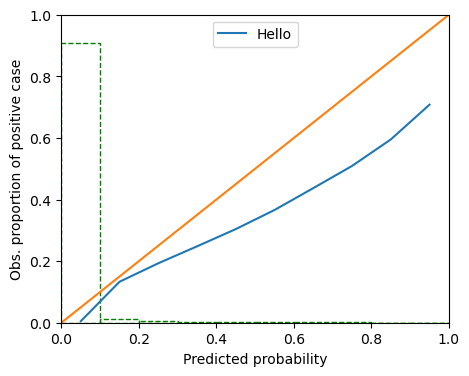

In [ ]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(test_data_y_t.flatten(), pred_y_test.flatten())

plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label='Hello')

plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [ ]:
from scipy.ndimage import uniform_filter

def compute_fss(observation, prediction, threshold=0.15, neighborhood_size=3):
    """
    Compute the Fraction Skill Score (FSS) for an observation and prediction.

    Parameters:
        observation (np.ndarray): Ground truth binary field (2D array).
        prediction (np.ndarray): Predicted binary field (2D array).
        threshold (float): Threshold to binarize the observation and prediction.
        neighborhood_size (int): Size of the moving window for fraction computation.

    Returns:
        float: Fraction Skill Score (FSS).
    """
    # Binarize observation and prediction
    obs_binary = (observation >= threshold).astype(float)
    pred_binary = (prediction >= threshold).astype(float)

    # Compute fractions using a uniform filter for the neighborhood
    obs_fraction = uniform_filter(obs_binary, size=neighborhood_size, mode='constant')
    pred_fraction = uniform_filter(pred_binary, size=neighborhood_size, mode='constant')

    # Compute the Mean Squared Error (MSE)
    mse = np.mean((obs_fraction - pred_fraction) ** 2)

    # Compute the reference MSE (MSE_ref)
    mse_ref = np.mean(obs_fraction ** 2 + pred_fraction ** 2)

    # Compute the Fraction Skill Score (FSS)
    fss = 1 - mse / mse_ref

    return fss

In [ ]:
model_save_path = Path(f'/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/model/zambia/lead-time-{lead_time}h/saved')                       
model_weights = f'zambia-model-multi-timesteps-64x64-t{lead_time}.pth'
model_scaler = f'zambia-model-multi-timesteps-64x64-t{lead_time}.bin'

dump(scaler, model_save_path/model_scaler)
torch.save(model.state_dict(), model_save_path/model_weights)